# StaySure Hotel Cancellation ML
## Milestone 8 — Final Test Evaluation and Model Documentation

**Business goal:** perform the one-time final evaluation of the frozen Milestone 6 policy on the untouched chronological test period, compare validation and test behavior, and document the model's intended use and limitations.

This notebook does **not** retrain the model, search hyperparameters, change the selected threshold, or choose a replacement model after test results are visible.

### Main outputs

- `reports/milestone_08_final_test_metrics.csv`
- `reports/milestone_08_validation_test_comparison.csv`
- `reports/milestone_08_test_confusion_matrix.csv`
- `reports/milestone_08_test_cohort_performance.csv`
- `reports/milestone_08_test_calibration.csv`
- `reports/milestone_08_model_card.csv`

### What you should be able to explain afterward

1. Why the final test set was opened only after model and threshold selection ended.
2. Why no tuning is allowed after viewing test results.
3. How validation-to-test differences reveal generalization risk.
4. Why ROC AUC, F1, recall, precision, and calibration answer different questions.
5. How false positives and false negatives affect hotel operations differently.
6. Why cohort results are diagnostics rather than a complete fairness audit.
7. What a model card communicates to technical and business stakeholders.

## 1. Setup

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, brier_score_loss, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
RANDOM_STATE = 42
print("Libraries loaded.")

Libraries loaded.


In [2]:
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
CLEAN_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "hotel_bookings_clean.csv"
PREPROCESSOR_PATH = PROJECT_ROOT / "models" / "preprocessing_pipeline.joblib"
TUNED_BUNDLE_PATH = PROJECT_ROOT / "models" / "random_forest_tuned_bundle.joblib"
FEATURE_MANIFEST_PATH = PROJECT_ROOT / "reports" / "milestone_03_feature_manifest.csv"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)

Project root: C:\Users\theko\ML_Projects\staysure-hotel-cancellation-ml


## 2. Load the frozen policy and establish the evaluation protocol

In [3]:
required_paths = [
    CLEAN_DATA_PATH,
    PREPROCESSOR_PATH,
    TUNED_BUNDLE_PATH,
    FEATURE_MANIFEST_PATH,
]
for required_path in required_paths:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required earlier-milestone artifact not found: {required_path}"
        )

manifest = pd.read_csv(FEATURE_MANIFEST_PATH)
FEATURE_COLUMNS = manifest["source_feature"].tolist()
TARGET = "is_canceled"

preprocessor = joblib.load(PREPROCESSOR_PATH)
tuned_bundle = joblib.load(TUNED_BUNDLE_PATH)
tuned_model = tuned_bundle["model"]
selected_threshold = float(tuned_bundle["threshold"])

assert tuned_bundle["feature_columns"] == FEATURE_COLUMNS
print("Frozen model:", type(tuned_model).__name__)
print("Frozen threshold:", round(selected_threshold, 2))
print("Frozen parameters:", tuned_bundle["selected_params"])

Frozen model: RandomForestClassifier
Frozen threshold: 0.45
Frozen parameters: {'n_estimators': 80, 'max_depth': 15, 'min_samples_leaf': 10, 'max_features': 0.5}


### Final-evaluation rule

The model, preprocessing pipeline, source features, and threshold above were fixed before the test set was opened. Test results may support a deployment decision, but they must not be used to modify this policy. Any future redevelopment requires a new holdout period.

## 3. Formally unseal the chronological test period

### TODO 1 — Confirm the one-time final evaluation

In [4]:
# TODO 1: Set to True only when the frozen policy is ready for final evaluation.
FINAL_TEST_UNSEALED = True

if FINAL_TEST_UNSEALED is not True:
    print("TODO 1: Confirm the one-time test evaluation by setting FINAL_TEST_UNSEALED = True.")
else:
    df = pd.read_csv(CLEAN_DATA_PATH)
    month_number = {month: number for number, month in enumerate([
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December",
    ], start=1)}
    df["arrival_date"] = pd.to_datetime({
        "year": df["arrival_date_year"],
        "month": df["arrival_date_month"].map(month_number),
        "day": df["arrival_date_day_of_month"],
    })
    df = df.sort_values("arrival_date").reset_index(drop=True)

    valid_df = df[
        (df["arrival_date"] > "2017-02-10")
        & (df["arrival_date"] <= "2017-05-21")
    ].copy()
    test_df = df[df["arrival_date"] > "2017-05-21"].copy()

    X_valid = valid_df[FEATURE_COLUMNS].copy()
    y_valid = valid_df[TARGET].copy()
    X_test = test_df[FEATURE_COLUMNS].copy()
    y_test = test_df[TARGET].copy()

    print("Validation period:", valid_df["arrival_date"].min().date(), "to", valid_df["arrival_date"].max().date())
    print("Final test period:", test_df["arrival_date"].min().date(), "to", test_df["arrival_date"].max().date())
    print("Validation:", X_valid.shape, f"cancellation rate={y_valid.mean():.2%}")
    print("Final test:", X_test.shape, f"cancellation rate={y_test.mean():.2%}")

Validation period: 2017-02-11 to 2017-05-21
Final test period: 2017-05-22 to 2017-08-31
Validation: (17758, 27) cancellation rate=39.47%
Final test: (17869, 27) cancellation rate=39.54%


Opening the test period is irreversible for this project. From this point forward, its results are evaluation evidence—not tuning feedback.

## 4. Apply the frozen pipeline and policy

In [5]:
if "X_test" not in globals():
    print("Complete TODO 1 first.")
else:
    X_valid_ready = preprocessor.transform(X_valid)
    X_test_ready = preprocessor.transform(X_test)

    assert X_valid_ready.shape[1] == X_test_ready.shape[1]
    assert tuned_model.n_features_in_ == X_test_ready.shape[1]

    valid_probabilities = tuned_model.predict_proba(X_valid_ready)[:, 1]
    test_probabilities = tuned_model.predict_proba(X_test_ready)[:, 1]
    valid_predictions = (valid_probabilities >= selected_threshold).astype(int)
    test_predictions = (test_probabilities >= selected_threshold).astype(int)

    print("Validation matrix:", X_valid_ready.shape)
    print("Final test matrix:", X_test_ready.shape)
    print("Threshold applied unchanged:", round(selected_threshold, 2))

Validation matrix: (17758, 522)
Final test matrix: (17869, 522)
Threshold applied unchanged: 0.45


## 5. Calculate validation and final-test metrics

In [6]:
def evaluate_policy(split_name, y_true, probabilities, predictions, threshold):
    tn, fp, fn, tp = confusion_matrix(
        y_true, predictions, labels=[0, 1]
    ).ravel()
    return {
        "split": split_name,
        "rows": len(y_true),
        "cancellation_rate": np.mean(y_true),
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
    }


if "test_predictions" not in globals():
    print("Complete TODO 1 first.")
else:
    validation_metrics = pd.DataFrame([evaluate_policy(
        "validation", y_valid, valid_probabilities,
        valid_predictions, selected_threshold,
    )])
    test_metrics = pd.DataFrame([evaluate_policy(
        "final_test", y_test, test_probabilities,
        test_predictions, selected_threshold,
    )])
    validation_test_comparison = pd.concat(
        [validation_metrics, test_metrics], ignore_index=True
    )
    display(validation_test_comparison.T)

,0,1
split,validation,final_test
rows,17758,17869
cancellation_rate,0.3947,0.3954
threshold,0.4500,0.4500
accuracy,0.7942,0.7343
precision,0.6926,0.6264
recall,0.8606,0.8127
f1,0.7675,0.7075
roc_auc,0.9000,0.8423
brier_score,0.1302,0.1646


The Brier score measures probability error; lower is better. ROC AUC measures ranking across thresholds, while precision, recall, and F1 depend on the frozen `0.45` operating threshold.

### TODO 2 — Quantify validation-to-test change

In [7]:
# TODO 2: Compare the six principal performance and calibration metrics.
DELTA_METRIC_COLUMNS = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "brier_score",
]

if DELTA_METRIC_COLUMNS is None:
    print("TODO 2: Choose the comparison metric columns.")
else:
    metric_deltas = pd.DataFrame({
        "metric": DELTA_METRIC_COLUMNS,
        "validation": [validation_metrics.loc[0, name] for name in DELTA_METRIC_COLUMNS],
        "final_test": [test_metrics.loc[0, name] for name in DELTA_METRIC_COLUMNS],
    })
    metric_deltas["test_minus_validation"] = (
        metric_deltas["final_test"] - metric_deltas["validation"]
    )
    display(metric_deltas)

,metric,validation,final_test,test_minus_validation
0,accuracy,0.7942,0.7343,-0.0599
1,precision,0.6926,0.6264,-0.0662
2,recall,0.8606,0.8127,-0.0479
3,f1,0.7675,0.7075,-0.0600
4,roc_auc,0.9000,0.8423,-0.0577
5,brier_score,0.1302,0.1646,0.0344


### TODO 3 — Interpret generalization

Summarize whether test performance is close enough to validation to support the same conclusions. Discuss metric direction, operational error costs, and why the test results cannot be used to retune the policy.

## FINAL EVALUATION
The frozen policy retained useful predictive power on the future test period, but performance was materially weaker than on validation. Accuracy declined by 0.0599, precision by 0.0662, recall by 0.0479, F1 by 0.0600, and ROC AUC by 0.0577. The Brier score increased by 0.0344, indicating that the predicted probabilities were also less accurate on future bookings. Although the final-test ROC AUC of 0.8423 and recall of 0.8127 show that the model still identifies a large share of cancellations, lower precision means more non-cancelling bookings would be incorrectly flagged, while lower recall means more actual cancellations would be missed. These results support only a cautious, monitored decision-support deployment rather than fully automated operational action. The frozen model and 0.45 threshold must not be retuned using these test results because doing so would convert the final test set into development data; any redevelopment should use a new training and validation process with a new untouched holdout period.

## 6. Inspect the final-test confusion matrix

,predicted_not_canceled,predicted_canceled
actual_not_canceled,7380,3424
actual_canceled,1323,5742


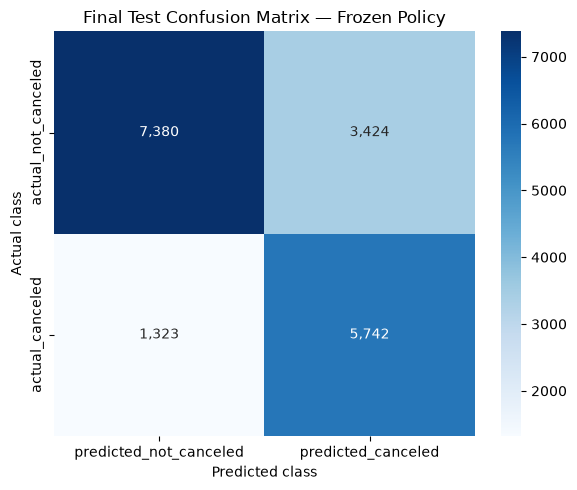

In [8]:
if "test_predictions" not in globals():
    print("Complete TODO 1 first.")
else:
    test_confusion = confusion_matrix(
        y_test, test_predictions, labels=[0, 1]
    )
    test_confusion_report = pd.DataFrame(
        test_confusion,
        index=["actual_not_canceled", "actual_canceled"],
        columns=["predicted_not_canceled", "predicted_canceled"],
    )
    display(test_confusion_report)

    plt.figure(figsize=(6, 5))
    sns.heatmap(test_confusion_report, annot=True, fmt=",d", cmap="Blues")
    plt.title("Final Test Confusion Matrix — Frozen Policy")
    plt.xlabel("Predicted class")
    plt.ylabel("Actual class")
    plt.tight_layout()
    plt.show()

## 7. Evaluate final-test probability calibration

,bin,mean_predicted_probability,observed_cancellation_rate,calibration_gap
0,1,0.0025,0.0011,0.0014
1,2,0.0417,0.0145,0.0272
2,3,0.1846,0.1204,0.0641
3,4,0.3471,0.2888,0.0584
4,5,0.4253,0.3693,0.0559
5,6,0.4836,0.4283,0.0552
6,7,0.5526,0.5109,0.0417
7,8,0.7740,0.6140,0.1600
8,9,0.8720,0.6659,0.2061
9,10,0.9731,0.9407,0.0324


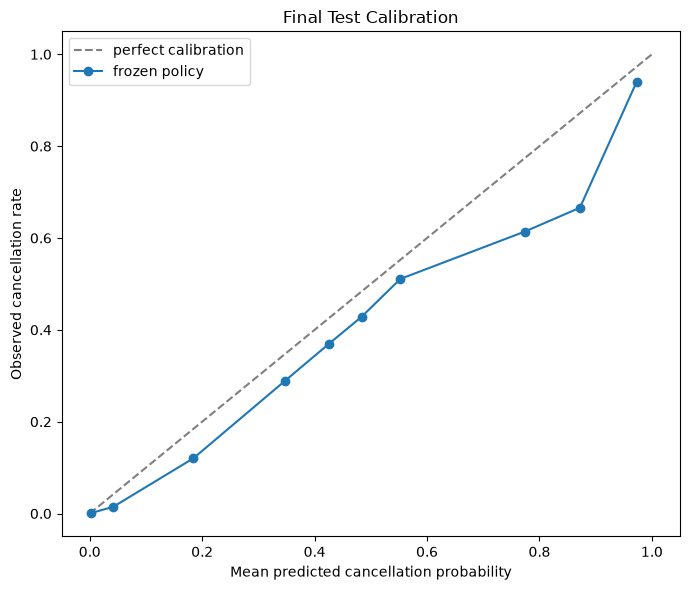

In [9]:
if "test_probabilities" not in globals():
    print("Complete TODO 1 first.")
else:
    observed_rate, mean_predicted_probability = calibration_curve(
        y_test, test_probabilities, n_bins=10, strategy="quantile"
    )
    test_calibration = pd.DataFrame({
        "bin": np.arange(1, len(observed_rate) + 1),
        "mean_predicted_probability": mean_predicted_probability,
        "observed_cancellation_rate": observed_rate,
    })
    test_calibration["calibration_gap"] = (
        test_calibration["mean_predicted_probability"]
        - test_calibration["observed_cancellation_rate"]
    )
    display(test_calibration)

    plt.figure(figsize=(7, 6))
    plt.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
    plt.plot(
        test_calibration["mean_predicted_probability"],
        test_calibration["observed_cancellation_rate"],
        marker="o",
        label="frozen policy",
    )
    plt.xlabel("Mean predicted cancellation probability")
    plt.ylabel("Observed cancellation rate")
    plt.title("Final Test Calibration")
    plt.legend()
    plt.tight_layout()
    plt.show()

Calibration checks whether a group assigned roughly 70% risk actually cancels about 70% of the time. Good ranking does not guarantee well-calibrated probabilities.

## 8. Compare performance across final-test cohorts

### TODO 4 — Select the established operational cohorts

In [10]:
# TODO 4: Reuse the same four operational cohorts from Milestone 7.
COHORT_COLUMNS = [
    "hotel",
    "market_segment",
    "deposit_type",
    "customer_type",
]
MIN_COHORT_ROWS = 100

if COHORT_COLUMNS is None:
    print("TODO 4: Choose the four cohort columns.")
else:
    test_results = test_df[
        ["arrival_date", TARGET] + FEATURE_COLUMNS
    ].reset_index(drop=True).copy()
    test_results["predicted_probability"] = test_probabilities
    test_results["predicted_class"] = test_predictions

    cohort_rows = []
    for cohort_column in COHORT_COLUMNS:
        for cohort_value, group in test_results.groupby(cohort_column, dropna=False):
            actual = group[TARGET].to_numpy()
            predicted = group["predicted_class"].to_numpy()
            group_tn, group_fp, group_fn, group_tp = confusion_matrix(
                actual, predicted, labels=[0, 1]
            ).ravel()
            cohort_rows.append({
                "cohort_feature": cohort_column,
                "cohort_value": cohort_value,
                "rows": len(group),
                "actual_cancellation_rate": actual.mean(),
                "predicted_cancellation_rate": predicted.mean(),
                "precision": precision_score(actual, predicted, zero_division=0),
                "recall": recall_score(actual, predicted, zero_division=0),
                "f1": f1_score(actual, predicted, zero_division=0),
                "false_positive_rate": (
                    group_fp / (group_fp + group_tn)
                    if group_fp + group_tn else np.nan
                ),
                "false_negative_rate": (
                    group_fn / (group_fn + group_tp)
                    if group_fn + group_tp else np.nan
                ),
                "true_negatives": group_tn,
                "false_positives": group_fp,
                "false_negatives": group_fn,
                "true_positives": group_tp,
            })

    test_cohort_performance = pd.DataFrame(cohort_rows)
    test_cohort_performance["stability_note"] = np.where(
        test_cohort_performance["rows"] < MIN_COHORT_ROWS,
        "small cohort — interpret cautiously",
        "reviewed cohort size",
    )
    display(
        test_cohort_performance
        .sort_values(["cohort_feature", "rows"], ascending=[True, False])
    )

,cohort_feature,cohort_value,rows,actual_cancellation_rate,predicted_cancellation_rate,precision,recall,f1,false_positive_rate,false_negative_rate,true_negatives,false_positives,false_negatives,true_positives,stability_note
14,customer_type,Transient,15167,0.4397,0.5664,0.6280,0.8090,0.7071,0.3761,0.1910,5302,3196,1274,5395,reviewed cohort size
15,customer_type,Transient-Party,2218,0.1474,0.2223,0.5700,0.8593,0.6854,0.1121,0.1407,1679,212,46,281,reviewed cohort size
12,customer_type,Contract,389,0.1542,0.1748,0.8676,0.9833,0.9219,0.0274,0.0167,320,9,1,59,reviewed cohort size
13,customer_type,Group,95,0.0947,0.1474,0.5000,0.7778,0.6087,0.0814,0.2222,79,7,2,7,small cohort — interpret cautiously
9,deposit_type,No Deposit,16524,0.3462,0.4739,0.5627,0.7701,0.6503,0.3169,0.2299,7379,3424,1315,4406,reviewed cohort size
10,deposit_type,Non Refund,1326,0.9992,0.9985,1.0000,0.9992,0.9996,0.0000,0.0008,1,0,1,1324,reviewed cohort size
11,deposit_type,Refundable,19,1.0000,0.6316,1.0000,0.6316,0.7742,NaN,0.3684,0,0,7,12,small cohort — interpret cautiously
0,hotel,City Hotel,12015,0.4057,0.5338,0.6112,0.8043,0.6945,0.3493,0.1957,4647,2494,954,3920,reviewed cohort size
1,hotel,Resort Hotel,5854,0.3743,0.4701,0.6621,0.8316,0.7372,0.2539,0.1684,2733,930,369,1822,reviewed cohort size
8,market_segment,Online TA,10825,0.4276,0.6152,0.5481,0.7885,0.6467,0.4856,0.2115,3187,3009,979,3650,reviewed cohort size


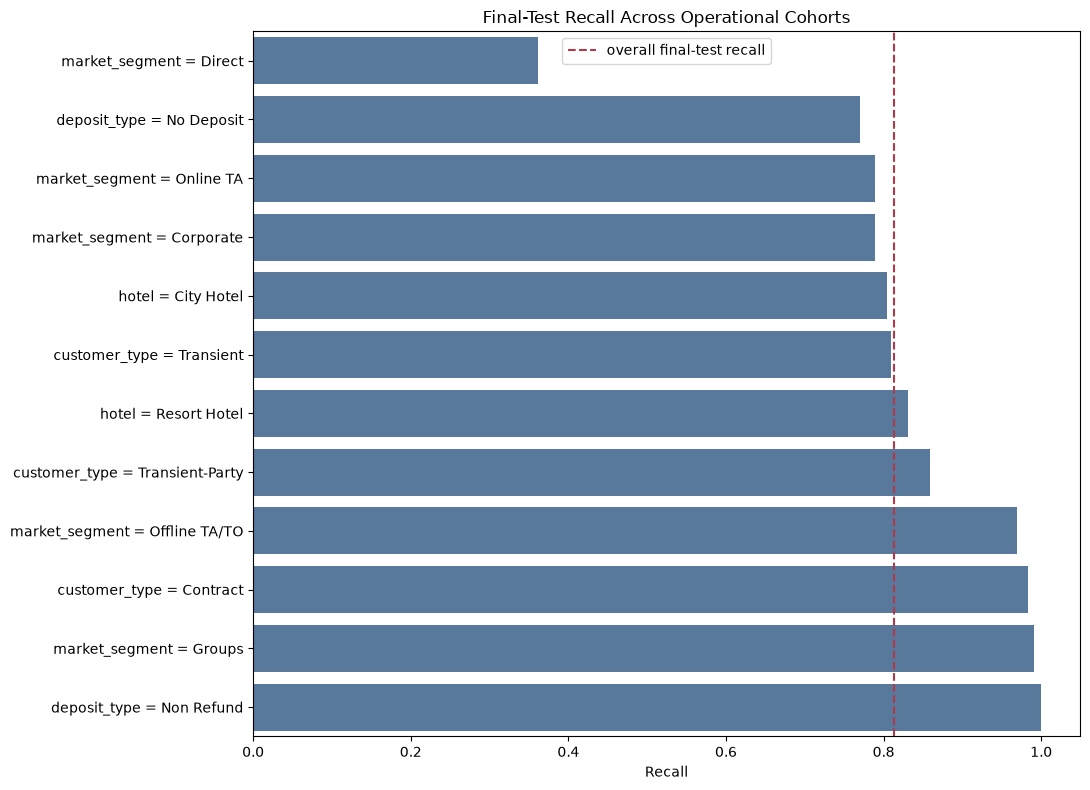

In [11]:
if "test_cohort_performance" not in globals():
    print("Complete TODO 4 first.")
else:
    stable_test_cohorts = test_cohort_performance[
        test_cohort_performance["rows"] >= MIN_COHORT_ROWS
    ].copy()
    plot_data = stable_test_cohorts.sort_values("recall")
    plot_data["cohort_label"] = (
        plot_data["cohort_feature"].astype(str)
        + " = "
        + plot_data["cohort_value"].astype(str)
    )
    plt.figure(figsize=(11, 8))
    sns.barplot(data=plot_data, x="recall", y="cohort_label", color="#4c78a8")
    plt.axvline(
        test_metrics.loc[0, "recall"],
        color="#b23a48",
        linestyle="--",
        label="overall final-test recall",
    )
    plt.title("Final-Test Recall Across Operational Cohorts")
    plt.xlabel("Recall")
    plt.ylabel("")
    plt.legend()
    plt.tight_layout()
    plt.show()

These cohort results are post-selection evaluation diagnostics. They can reveal where monitoring or human review is especially important, but they do not constitute a full protected-class fairness audit.

## 9. Create the final model card

In [12]:
if "test_metrics" not in globals() or "test_cohort_performance" not in globals():
    print("Complete the earlier TODOs first.")
else:
    model_card = pd.DataFrame([
        {"field": "model_name", "value": "StaySure hotel cancellation frozen random forest"},
        {"field": "model_type", "value": type(tuned_model).__name__},
        {"field": "operating_threshold", "value": selected_threshold},
        {"field": "test_period", "value": f"{test_df['arrival_date'].min().date()} to {test_df['arrival_date'].max().date()}"},
        {"field": "test_rows", "value": len(test_df)},
        {"field": "test_roc_auc", "value": test_metrics.loc[0, "roc_auc"]},
        {"field": "test_f1", "value": test_metrics.loc[0, "f1"]},
        {"field": "test_precision", "value": test_metrics.loc[0, "precision"]},
        {"field": "test_recall", "value": test_metrics.loc[0, "recall"]},
        {"field": "test_brier_score", "value": test_metrics.loc[0, "brier_score"]},
        {"field": "intended_use", "value": "Human-reviewed operational prioritization and planning"},
        {"field": "prohibited_use", "value": "Automatic denial, penalties, or contractual changes"},
        {"field": "known_limitations", "value": "Historical bias, proxy risk, cohort error variation, drift, and non-causal explanations"},
        {"field": "monitoring", "value": "Track inputs, calibration, overall and cohort errors, and business outcomes"},
        {"field": "retraining_rule", "value": "Any redevelopment requires a new untouched holdout period"},
        {"field": "final_test_status", "value": "opened once for final evaluation; not used for tuning"},
    ])
    display(model_card)

,field,value
0,model_name,StaySure hotel cancellation frozen random forest
1,model_type,RandomForestClassifier
2,operating_threshold,0.4500
3,test_period,2017-05-22 to 2017-08-31
4,test_rows,17869
5,test_roc_auc,0.8423
6,test_f1,0.7075
7,test_precision,0.6264
8,test_recall,0.8127
9,test_brier_score,0.1646


### TODO 5 — State the deployment recommendation

Based on the final-test evidence, state whether the model is suitable for a monitored pilot, needs additional non-test investigation, or should not be deployed. Include the human-review boundary and the most important monitoring priorities.

## DEPLOYMENT RECOMMENDATION
The model is suitable for a limited, monitored pilot as a decision-support tool, but it should not be used for fully automated operational decisions. The final-test ROC AUC of 0.8423 and recall of 0.8127 demonstrate useful cancellation-risk detection, while the lower precision of 0.6264, F1 score of 0.7075, and weaker Brier score of 0.1646 show meaningful generalization and calibration risk. A prediction above the frozen 0.45 threshold should trigger human review or proportionate customer outreach only; it must not independently cause a reservation to be cancelled, denied, penalized, or subjected to an irreversible action. Pilot monitoring should track precision, recall, false-positive and false-negative rates, calibration, cancellation prevalence, feature drift, and performance across hotel, market-segment, deposit-type, and customer-type cohorts. Particular attention should be given to cohorts with weak recall, small sample sizes, or materially different error rates. Any recalibration, threshold adjustment, or model redevelopment must use new development data and a new untouched holdout period rather than the opened final test set.

## 10. Save the final evaluation reports

### TODO 6 — Save the six reproducible reports

In [13]:
required_report_objects = [
    "test_metrics",
    "validation_test_comparison",
    "test_confusion_report",
    "test_cohort_performance",
    "test_calibration",
    "model_card",
]

if any(name not in globals() for name in required_report_objects):
    print("Complete the earlier TODOs first.")
else:
    # TODO 6: Replace None with the final-test metric report.
    FINAL_TEST_METRICS_TO_SAVE = test_metrics

    if FINAL_TEST_METRICS_TO_SAVE is None:
        print("TODO 6: Choose the final-test metric report to save.")
    else:
        FINAL_TEST_METRICS_TO_SAVE.to_csv(
            REPORTS_DIR / "milestone_08_final_test_metrics.csv", index=False
        )
        validation_test_comparison.to_csv(
            REPORTS_DIR / "milestone_08_validation_test_comparison.csv", index=False
        )
        test_confusion_report.to_csv(
            REPORTS_DIR / "milestone_08_test_confusion_matrix.csv"
        )
        test_cohort_performance.to_csv(
            REPORTS_DIR / "milestone_08_test_cohort_performance.csv", index=False
        )
        test_calibration.to_csv(
            REPORTS_DIR / "milestone_08_test_calibration.csv", index=False
        )
        model_card.to_csv(
            REPORTS_DIR / "milestone_08_model_card.csv", index=False
        )
        print("Six Milestone 8 reports saved.")

Six Milestone 8 reports saved.


In [14]:
report_paths = [
    REPORTS_DIR / "milestone_08_final_test_metrics.csv",
    REPORTS_DIR / "milestone_08_validation_test_comparison.csv",
    REPORTS_DIR / "milestone_08_test_confusion_matrix.csv",
    REPORTS_DIR / "milestone_08_test_cohort_performance.csv",
    REPORTS_DIR / "milestone_08_test_calibration.csv",
    REPORTS_DIR / "milestone_08_model_card.csv",
]

if all(path.exists() for path in report_paths):
    assert FINAL_TEST_UNSEALED is True
    assert np.isclose(test_metrics.loc[0, "threshold"], tuned_bundle["threshold"])
    assert tuned_bundle["feature_columns"] == FEATURE_COLUMNS
    assert set(COHORT_COLUMNS) == {
        "hotel", "market_segment", "deposit_type", "customer_type"
    }
    assert test_metrics.loc[0, "rows"] == len(test_df)
    assert test_confusion_report.to_numpy().sum() == len(test_df)
    assert set(model_card["field"]) >= {
        "intended_use", "prohibited_use", "final_test_status"
    }
    print("Milestone 8 final-evaluation checks passed.")
else:
    print("Complete TODO 6 and save all reports first.")

Milestone 8 final-evaluation checks passed.


## Interview-ready summary

Complete this after running the notebook:

> I evaluated the frozen StaySure random-forest policy once on the untouched chronological test period. I applied the previously selected preprocessing pipeline, model, features, and threshold without modification. I compared validation and test discrimination, threshold metrics, confusion-matrix errors, probability calibration, and operational cohort performance. I documented intended and prohibited uses in a final model card. Test results were used only for final evaluation and deployment judgment—not for further tuning.

## Questions you should be ready to answer

1. Why was the test set opened only after model and threshold selection ended?
2. Why would changing the threshold after test evaluation be leakage?
3. What does a validation-to-test performance drop indicate?
4. How do ROC AUC and F1 describe different aspects of performance?
5. What does the Brier score measure?
6. Why can a model rank risk well but still be poorly calibrated?
7. What operational costs come from false positives and false negatives?
8. Why should small-cohort results be interpreted cautiously?
9. What information belongs in a model card?
10. What would justify a monitored pilot rather than unrestricted deployment?

## Interview Answers
1. Why was the test set opened only after model and threshold selection ended?
   The test set represents future, unseen data and provides an unbiased estimate of generalization. Keeping it sealed prevents its outcomes from influencing model selection, preprocessing, hyperparameters, or the operating threshold.
2. Why would changing the threshold after test evaluation be leakage?
   Changing the threshold in response to test results would use test information to improve the policy. The test set would effectively become validation data, making the reported performance overly optimistic. Further tuning requires new development data and a new untouched holdout set.
3. What does a validation-to-test performance drop indicate?
   It suggests the model generalizes less effectively to the later time period. Possible causes include temporal distribution shift, changing customer behavior, new category patterns, or validation performance that was somewhat optimistic. In this project, ROC AUC declined from 0.9000 to 0.8423, while F1 declined from 0.7675 to 0.7075.
4. How do ROC AUC and F1 describe different aspects of performance?
   ROC AUC measures how well the model ranks cancellations above non-cancellations across all possible thresholds. F1 measures the balance between precision and recall at the selected operating threshold—0.45 in this project. A model can rank risks well but perform less effectively at one particular threshold.
5. What does the Brier score measure?
   The Brier score measures the mean squared difference between predicted probabilities and actual binary outcomes. Lower values are better. The increase from 0.1302 on validation to 0.1646 on the final test set indicates less accurate probability estimates on future bookings.
6. Why can a model rank risk well but still be poorly calibrated?
   Ranking and calibration measure different properties. A model may correctly order higher-risk bookings above lower-risk bookings while assigning probabilities that are systematically too high or too low. Therefore, strong ROC AUC does not guarantee that a predicted 70% risk corresponds to an actual cancellation rate near 70%.
7. What operational costs come from false positives and false negatives?
   False positives incorrectly flag bookings that will not cancel, potentially causing unnecessary outreach, staff workload, customer friction, or inappropriate inventory actions. False negatives miss actual cancellations, reducing opportunities for intervention and potentially causing lost revenue or unused rooms. The acceptable balance depends on the cost of each error.
8. Why should small-cohort results be interpreted cautiously?
   Metrics calculated from small samples are unstable and can change substantially because of only a few predictions. Extreme precision or recall values may reflect limited observations rather than reliable performance. Cohort size, cancellation prevalence, and uncertainty should be reviewed alongside the metric.
9. What information belongs in a model card?
   A model card should document the model’s purpose, model type, input features, target, training and evaluation periods, preprocessing, parameters, threshold, performance metrics, intended use, prohibited uses, limitations, cohort findings, monitoring requirements, human-review boundaries, and retraining rules.
10. What would justify a monitored pilot rather than unrestricted deployment?
    A monitored pilot is appropriate when the model retains useful predictive power but shows generalization, calibration, or cohort-performance concerns. Here, final-test ROC AUC was 0.8423 and recall was 0.8127, but precision fell to 0.6264, F1 to 0.7075, and calibration weakened. The model should therefore support human review and proportionate outreach—not independently cancel, deny, penalize, or otherwise take irreversible action on a reservation.

## Milestone 8 completion checklist

- [x] Loaded the frozen Milestone 6 model, pipeline, features, and threshold
- [x] Formally opened the chronological test period only for final evaluation
- [x] Made no post-test model or threshold changes
- [x] Compared validation and final-test metrics
- [x] Reviewed the final-test confusion matrix
- [x] Evaluated probability calibration
- [x] Compared performance across established operational cohorts
- [x] Documented intended use, prohibited use, limitations, and monitoring
- [x] Saved six reproducible final-evaluation reports
- [x] Can explain why future redevelopment requires a new holdout period